In [61]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [36]:
from google.colab import files

uploaded = files.upload()

Saving skill_gap_dataset_realistic.xlsx to skill_gap_dataset_realistic.xlsx


In [62]:
import pandas as pd

df = pd.read_excel("skill_gap_dataset_realistic.xlsx")

In [63]:
df.head(10)

,Skill_Name,Curriculum_Coverage,Industry_Demand,Job_Frequency,Expert_Importance,Gap_Status
0,Python,5,5,10,5,Aligned
1,Java,5,4,9,5,Aligned
2,C++,5,3,7,4,Aligned
3,SQL,4,5,9,5,Aligned
4,DBMS,5,4,8,5,Aligned
5,Operating Systems,5,3,6,4,Aligned
6,Computer Networks,4,4,7,4,Aligned
7,Machine Learning,2,5,9,5,Gap
8,Deep Learning,1,5,8,5,Gap
9,Generative AI,1,5,10,5,Gap


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Skill_Name           100 non-null    object
 1   Curriculum_Coverage  100 non-null    int64 
 2   Industry_Demand      100 non-null    int64 
 3   Job_Frequency        100 non-null    int64 
 4   Expert_Importance    100 non-null    int64 
 5   Gap_Status           100 non-null    object
dtypes: int64(4), object(2)
memory usage: 4.8+ KB


In [65]:
df.describe()

,Curriculum_Coverage,Industry_Demand,Job_Frequency,Expert_Importance
count,100.000000,100.000000,100.000000,100.000000
mean,3.180000,4.560000,7.910000,4.760000
std,1.465978,0.656283,1.064534,0.429235
min,1.000000,3.000000,5.000000,4.000000
25%,2.000000,4.000000,7.000000,5.000000
50%,3.000000,5.000000,8.000000,5.000000
75%,5.000000,5.000000,9.000000,5.000000
max,5.000000,5.000000,10.000000,5.000000


In [66]:
df.isnull().sum()

,0
Skill_Name,0
Curriculum_Coverage,0
Industry_Demand,0
Job_Frequency,0
Expert_Importance,0
Gap_Status,0


In [67]:
df.duplicated().sum()

np.int64(36)

In [68]:
X=df[[
    "Curriculum_Coverage",
    "Industry_Demand",
    "Job_Frequency",
    "Expert_Importance"
]]

y=df["Gap_Status"]

In [69]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [70]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
prediction=model.predict(X_test)

In [71]:
accuracy=accuracy_score(y_test,prediction)

print("Accuracy :",accuracy)

Accuracy : 0.84


In [72]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

     Aligned       0.87      0.87      0.87        15
         Gap       0.80      0.80      0.80        10

    accuracy                           0.84        25
   macro avg       0.83      0.83      0.83        25
weighted avg       0.84      0.84      0.84        25



In [73]:
print(confusion_matrix(y_test,prediction))

[[13  2]
 [ 2  8]]


In [74]:
new_skill=pd.DataFrame({
    "Curriculum_Coverage":[2],
    "Industry_Demand":[5],
    "Job_Frequency":[8],
    "Expert_Importance":[5]
})

result=model.predict(new_skill)

print(result)

['Gap']


In [75]:
new_skill=pd.DataFrame({
    "Curriculum_Coverage":[5],
    "Industry_Demand":[4],
    "Job_Frequency":[8],
    "Expert_Importance":[5]
})

print(model.predict(new_skill))

['Aligned']


In [76]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=2,
    max_leaf_nodes=4,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, max_leaf_nodes=4, min_samples_split=10,
                       random_state=42)

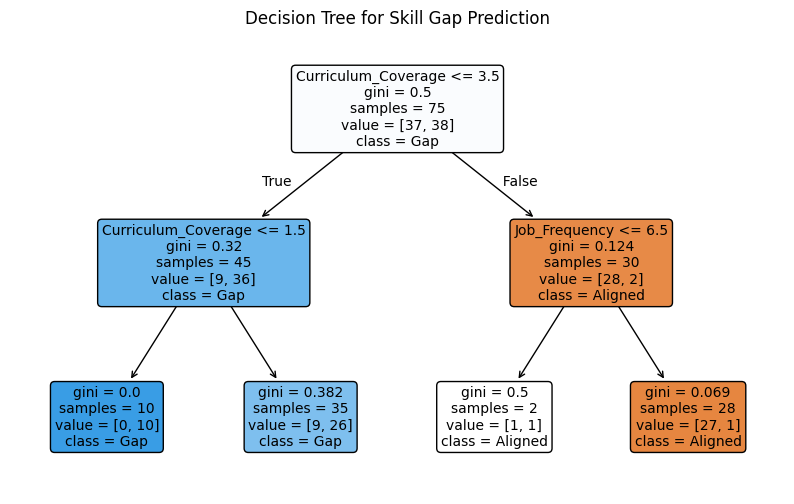

In [77]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Aligned", "Gap"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Skill Gap Prediction")
plt.show()

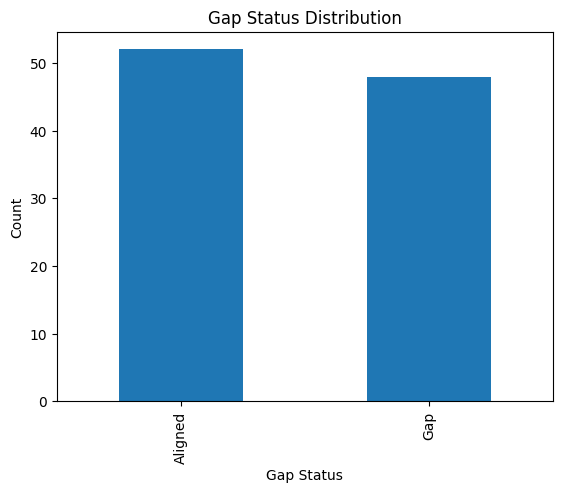

In [78]:
df["Gap_Status"].value_counts().plot(kind="bar")

plt.title("Gap Status Distribution")
plt.xlabel("Gap Status")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_1120/1973543563.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corr = df.drop("Skill_Name", axis=1).replace({"Aligned":0,"Gap":1}).corr()


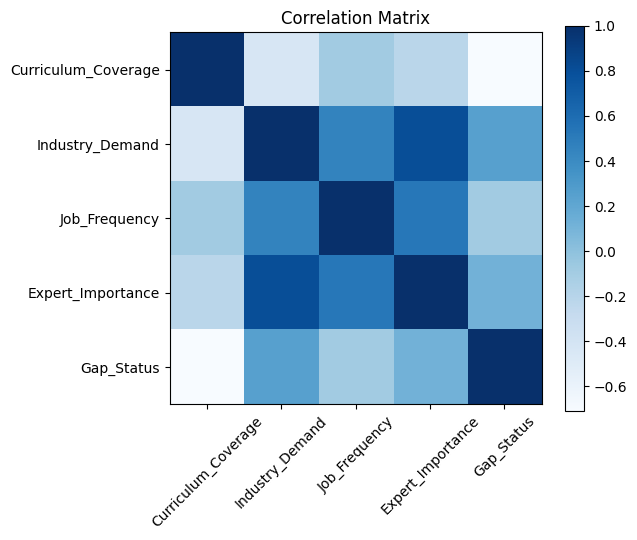

In [79]:
import matplotlib.pyplot as plt

corr = df.drop("Skill_Name", axis=1).replace({"Aligned":0,"Gap":1}).corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()